### 1. Импорты

In [77]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path

### 2. Загрузка данных

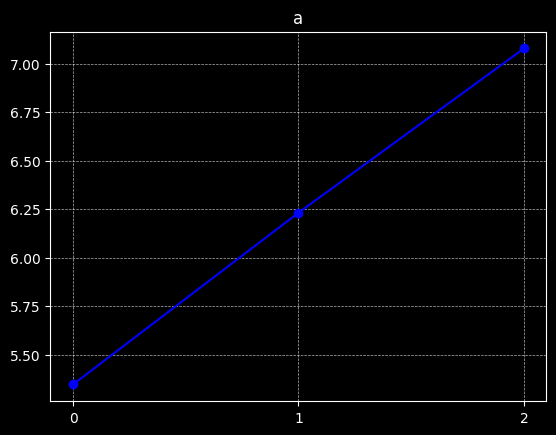

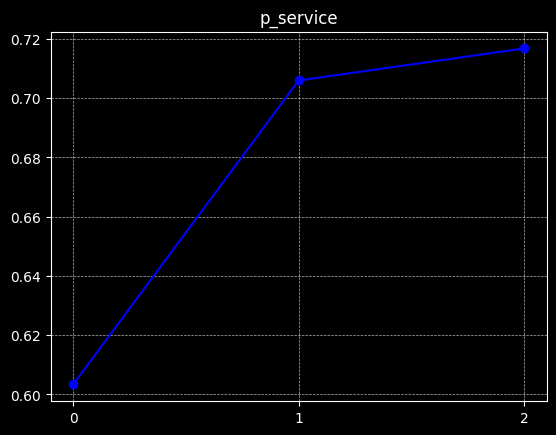

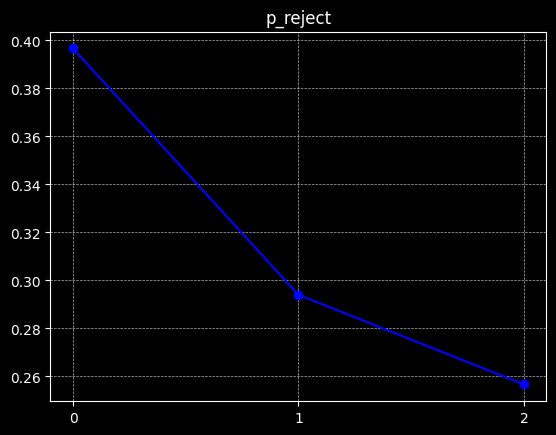

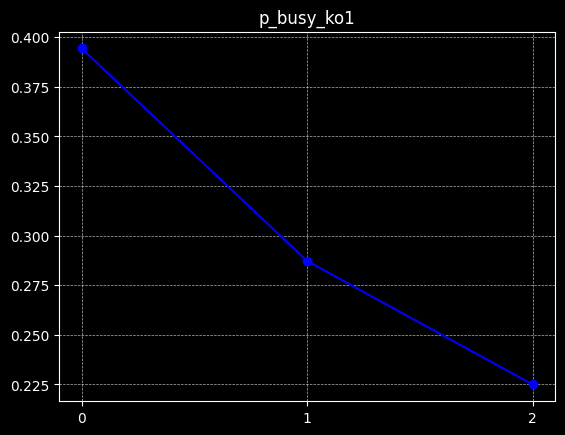

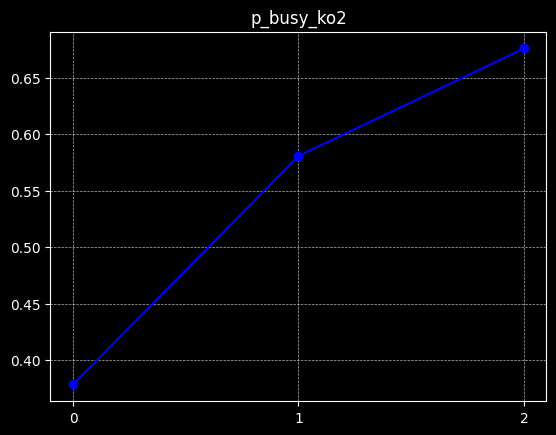

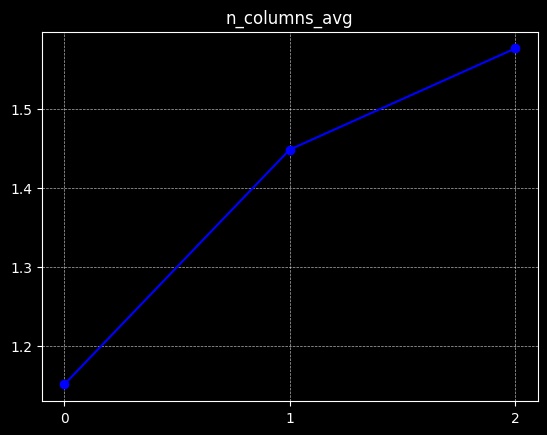

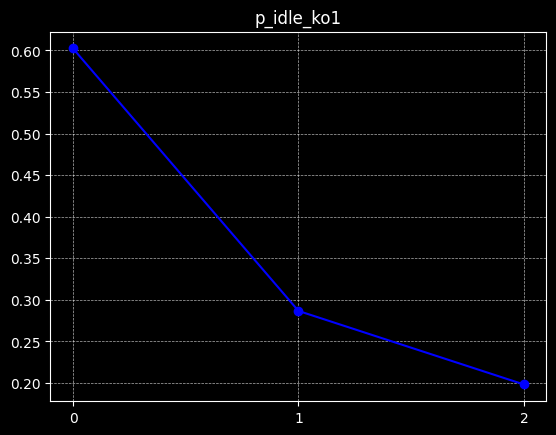

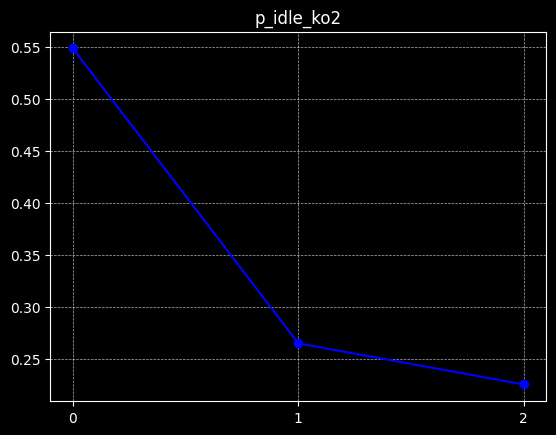

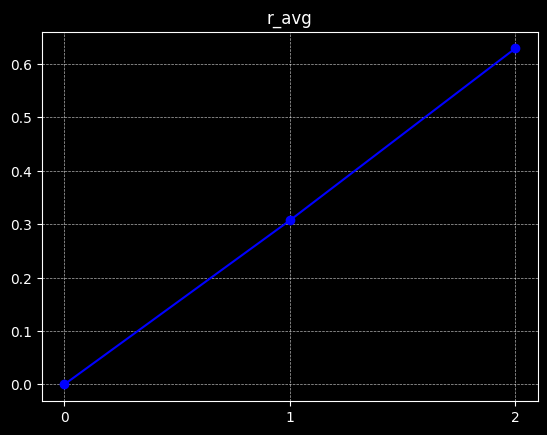

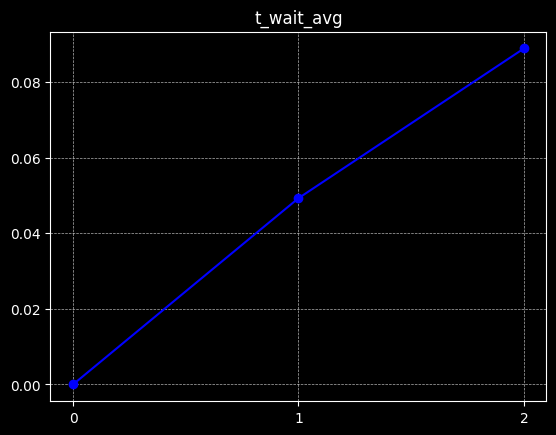

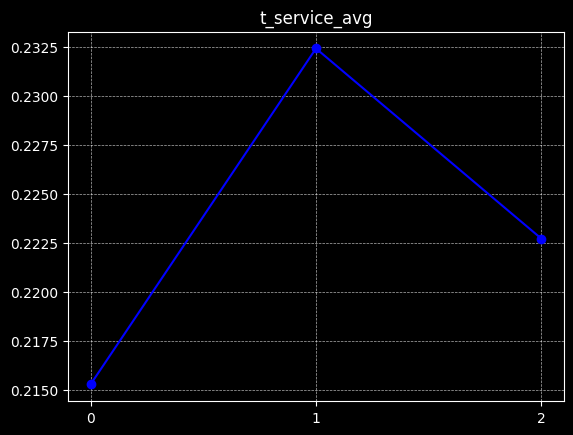

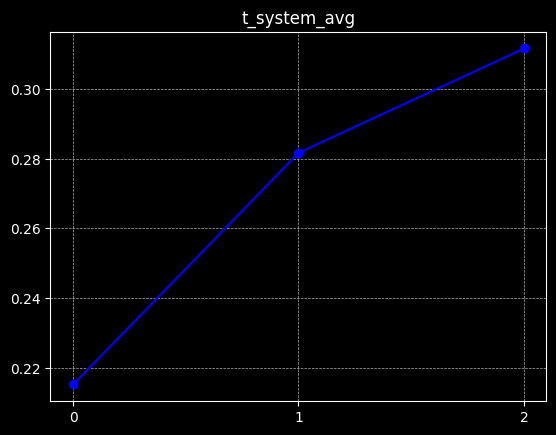

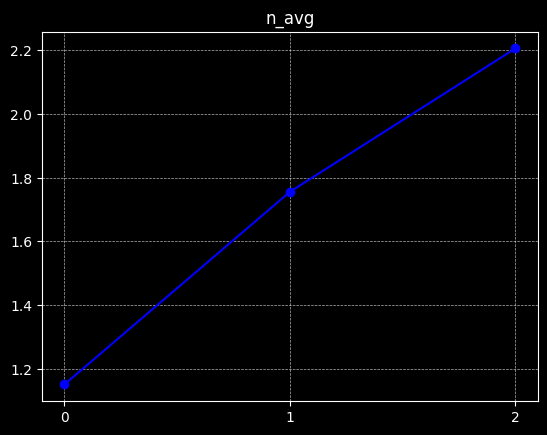

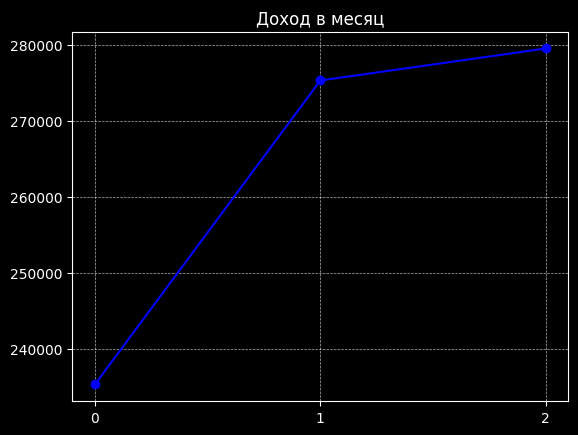

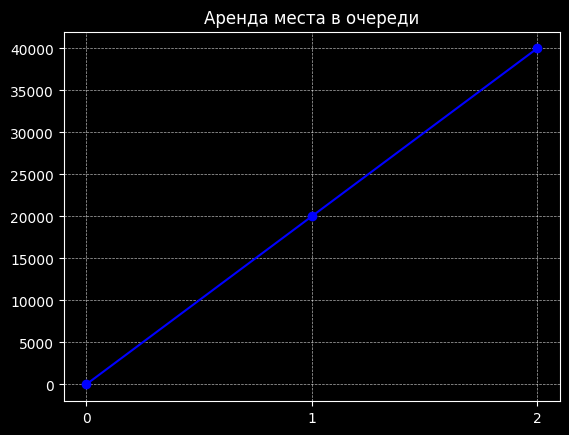

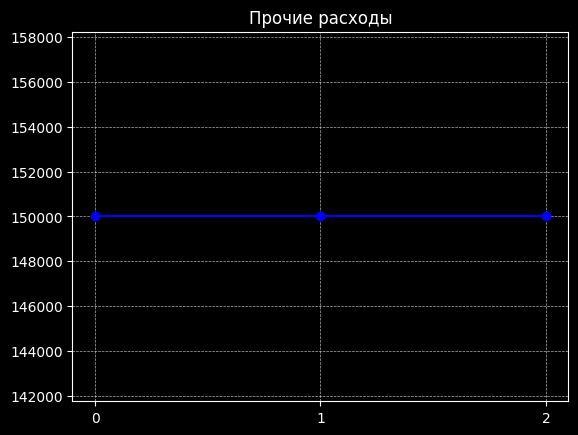

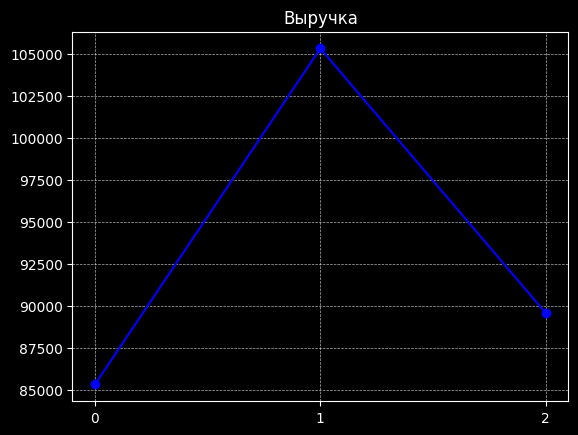

In [78]:
FILENAME = "results.csv"
BASE_DIR = Path.cwd()

def get_data_csv(path):
    if not path.exists():
        print("Файл не найден")
        return {}
    try:
        with open(path, "r", newline="") as file:
            reader = csv.reader(file)
            return {row[0]: row[1] for row in reader}

    except Exception as e:
        print(f"Ошибка работы с файлом {path}. {e}")
        return {}
data = {}
for i in range(3):
    path = BASE_DIR / f'{i}_queue_of_car' / FILENAME
    data_queue = get_data_csv(path)
    for key, value in data_queue.items():
        value = float(value)
        data[key] = [value] if key not in data else data[key] + [value]

rent_place = 20000
data["Доход в месяц"] = [i*1000*390 for i in data["p_service"]]
data["Аренда места в очереди"] = [i*rent_place for i in range(3)]
expenses = 150000
data["Прочие расходы"] = [expenses] * 3
data["Выручка"] = [-rent_place*i - expenses  + data["Доход в месяц"][i] for i in range(3)]

for key, value in data.items():
    figure, axes = plt.subplots()
    axes.plot([0,1,2], value, "ob-")
    axes.grid(True, which="major", axis="both", linestyle="--", linewidth=0.5, alpha=0.7)
    axes.set_xticks([0,1,2])
    plt.title(key)
    plt.show()



Режим работы каждый день с 9 до 22 часов. 13 часов в день.
В месяц получается 13*30=390 часов. Предположим средний чек с автомобиля = 1000 руб.
Тогда домножив его на пропускную способность получим средний доход заправки в месяц.
Предположим аренда одного места в очереди нам обойдется в 20 тыс. руб.
Средние расходы заправки в месяц = 150 тыс. руб.

```Ср. выручка = ср. доход - аренда мест - прочие расходы```